In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.phase_space_reconstruction import delay_embedding, cao_method
# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("Đang khởi tạo dữ liệu và bơm nhiễu...")

# Lấy trục X của Lorenz và bơm nhiễu trắng (SNR = 15 dB)
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0][:3000]
white_noisy_x = add_white_noise(clean_x, snr_db=15.0)
N_T = len(white_noisy_x)
colered_noise_x = add_colored_noise(clean_x, snr_db=15.0, color='pink')

Đang khởi tạo dữ liệu và bơm nhiễu...


2. Đang tính toán đại lượng E1 và E2 (tau=15)...
3. Đang vẽ đồ thị đối chứng...


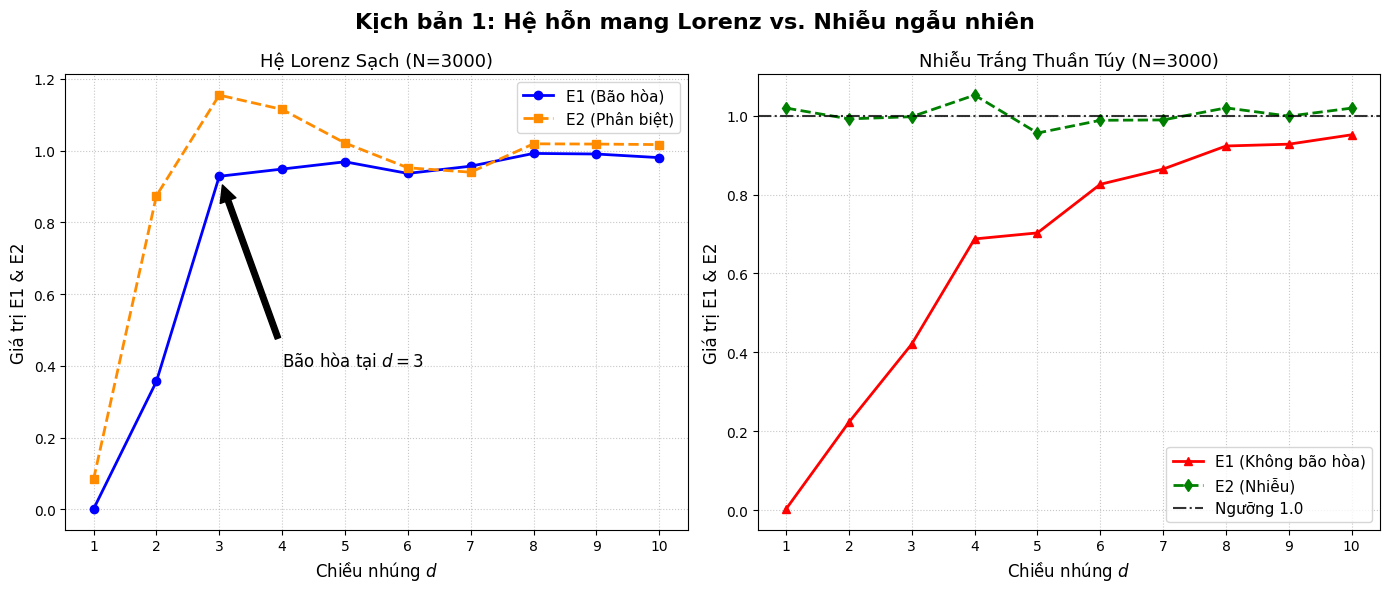

In [4]:
# Tạo Nhiễu trắng ngẫu nhiên thuần túy (Random Noise) với độ lệch chuẩn tương đương
pure_noise = np.random.normal(0, np.std(clean_x), 3000)

# =====================================================================
# 2. CHẠY PHƯƠNG PHÁP CAO (1997)
# =====================================================================
print("2. Đang tính toán đại lượng E1 và E2 (tau=15)...")
tau_optimal = 15
max_dim = 10

# Chạy thuật toán cho Lorenz Sạch
dims, E1_lorenz, E2_lorenz = cao_method(clean_x, tau=tau_optimal, max_m=max_dim)

# Chạy thuật toán cho Nhiễu Thuần túy
dims, E1_noise, E2_noise = cao_method(pure_noise, tau=tau_optimal, max_m=max_dim)

# =====================================================================
# 3. TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
print("3. Đang vẽ đồ thị đối chứng...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Kịch bản 1: Hệ hỗn mang Lorenz vs. Nhiễu ngẫu nhiên", fontsize=16, fontweight='bold')

# Đồ thị 1: Hệ Lorenz (Bão hòa & Dao động)
axes[0].plot(dims, E1_lorenz, marker='o', markersize=6, linewidth=2, color='blue', label='E1 (Bão hòa)')
axes[0].plot(dims, E2_lorenz, marker='s', markersize=6, linewidth=2, linestyle='--', color='darkorange', label='E2 (Phân biệt)')
axes[0].set_title("Hệ Lorenz Sạch (N=3000)", fontsize=13)
axes[0].set_xlabel("Chiều nhúng $d$", fontsize=12)
axes[0].set_ylabel("Giá trị E1 & E2", fontsize=12)
axes[0].set_xticks(dims)
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(fontsize=11)

# Highlight điểm bão hòa của Lorenz
axes[0].annotate('Bão hòa tại $d=3$', xy=(3, E1_lorenz[2]), xytext=(4, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

# Đồ thị 2: Nhiễu ngẫu nhiên (Không bão hòa & Bám mốc 1.0)
axes[1].plot(dims, E1_noise, marker='^', markersize=6, linewidth=2, color='red', label='E1 (Không bão hòa)')
axes[1].plot(dims, E2_noise, marker='d', markersize=6, linewidth=2, linestyle='--', color='green', label='E2 (Nhiễu)')
axes[1].axhline(y=1.0, color='black', linestyle='-.', alpha=0.8, label='Ngưỡng 1.0')
axes[1].set_title("Nhiễu Trắng Thuần Túy (N=3000)", fontsize=13)
axes[1].set_xlabel("Chiều nhúng $d$", fontsize=12)
axes[1].set_ylabel("Giá trị E1 & E2", fontsize=12)
axes[1].set_xticks(dims)
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

1. Đang khởi tạo dữ liệu Lorenz và bơm nhiễu 15dB...
2. Đang tính toán E1 và E2 (tau=15)...
3. Đang vẽ đồ thị...


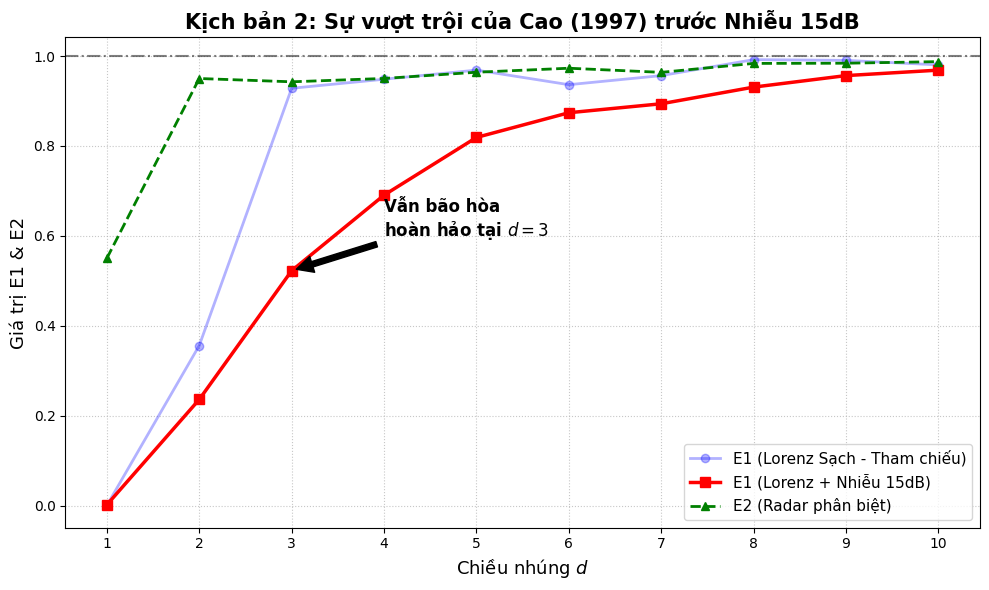

In [7]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise
from core_ntsa.phase_space_reconstruction import cao_method

# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("1. Đang khởi tạo dữ liệu Lorenz và bơm nhiễu 15dB...")
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0][:3000] 

# Bơm nhiễu 15dB để tạo "sương mù" bao phủ quỹ đạo
noisy_x = add_white_noise(clean_x, snr_db=15.0)

# =====================================================================
# 2. CHẠY PHƯƠNG PHÁP CAO (1997)
# =====================================================================
print("2. Đang tính toán E1 và E2 (tau=15)...")
tau_optimal = 15
max_dim = 10

# Chạy thuật toán cho cả 2 chuỗi để vẽ đối chiếu
dims, E1_clean, _ = cao_method(clean_x, tau=tau_optimal, max_m=max_dim)
dims, E1_noisy, E2_noisy = cao_method(noisy_x, tau=tau_optimal, max_m=max_dim)

# =====================================================================
# 3. TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
print("3. Đang vẽ đồ thị...")
plt.figure(figsize=(10, 6))
plt.title("Kịch bản 2: Sự vượt trội của Cao (1997) trước Nhiễu 15dB", fontsize=15, fontweight='bold')

# Vẽ đường E1 của Lorenz Sạch mờ ở dưới để làm hệ quy chiếu
plt.plot(dims, E1_clean, marker='o', markersize=6, linewidth=2, color='blue', alpha=0.3, label='E1 (Lorenz Sạch - Tham chiếu)')

# Vẽ E1 và E2 của dữ liệu có nhiễu
plt.plot(dims, E1_noisy, marker='s', markersize=7, linewidth=2.5, color='red', label='E1 (Lorenz + Nhiễu 15dB)')
plt.plot(dims, E2_noisy, marker='^', markersize=6, linewidth=2, linestyle='--', color='green', label='E2 (Radar phân biệt)')

plt.axhline(y=1.0, color='black', linestyle='-.', alpha=0.5)

# Đánh dấu điểm bão hòa
plt.annotate('Vẫn bão hòa\nhoàn hảo tại $d=3$', xy=(3, E1_noisy[2]), xytext=(4, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, fontweight='bold')

plt.xlabel("Chiều nhúng $d$", fontsize=13)
plt.ylabel("Giá trị E1 & E2", fontsize=13)
plt.xticks(dims)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

1. Đang khởi tạo dữ liệu Lorenz...
2. Đang tính toán E1 và E2 (tau=15)...
3. Đang vẽ đồ thị đối chứng...


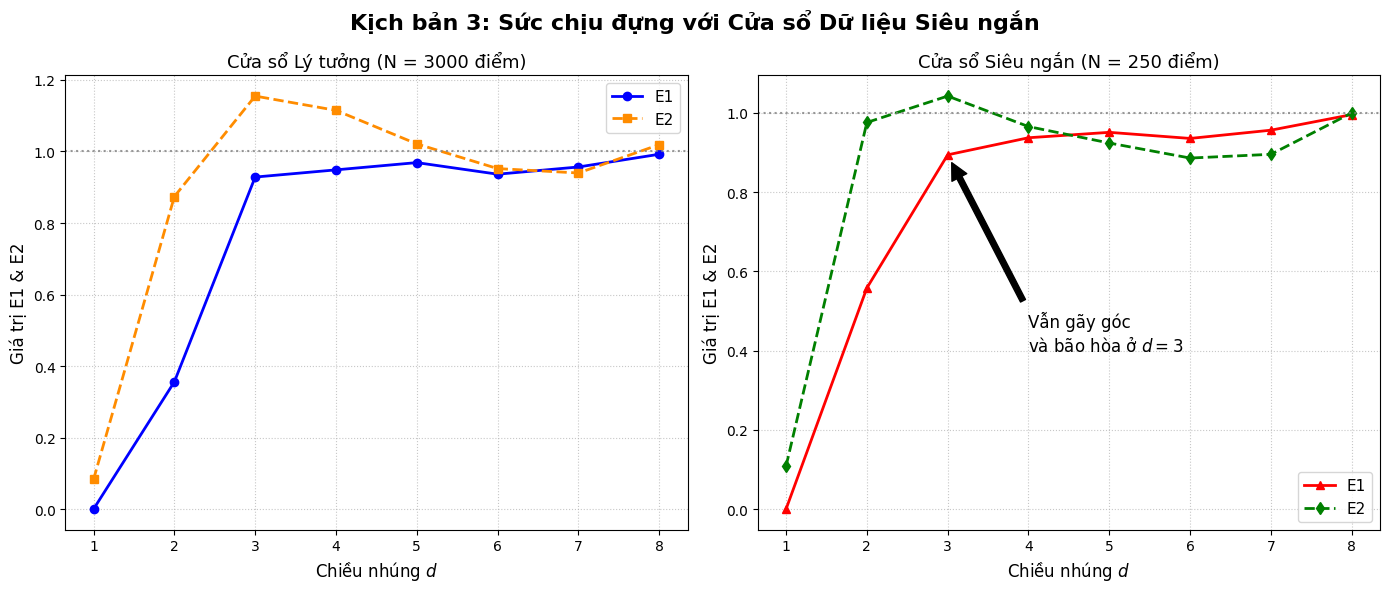

In [10]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.phase_space_reconstruction import cao_method

# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("1. Đang khởi tạo dữ liệu Lorenz...")
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)

# Cắt 2 tập dữ liệu: Dài (Lý tưởng) và Ngắn (Thực chiến Cửa sổ trượt)
clean_x_long = lorenz_data[0][:3000]   # 3000 điểm (Rất nhiều dữ liệu)
clean_x_short = lorenz_data[0][:1000]   # 250 điểm (Tương đương cửa sổ 5s ở 50Hz)

# =====================================================================
# 2. CHẠY PHƯƠNG PHÁP CAO (1997)
# =====================================================================
print("2. Đang tính toán E1 và E2 (tau=15)...")
tau_optimal = 15
max_dim = 8  # Giới hạn m=8 để phù hợp với N=250 và tau=15

# Chạy thuật toán song song
dims, E1_long, E2_long = cao_method(clean_x_long, tau=tau_optimal, max_m=max_dim)
dims, E1_short, E2_short = cao_method(clean_x_short, tau=tau_optimal, max_m=max_dim)

# =====================================================================
# 3. TRỰC QUAN HÓA KẾT QUẢ SO SÁNH
# =====================================================================
print("3. Đang vẽ đồ thị đối chứng...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Kịch bản 3: Sức chịu đựng với Cửa sổ Dữ liệu Siêu ngắn", fontsize=16, fontweight='bold')

# Đồ thị 1: Cửa sổ lý tưởng (N=3000)
axes[0].plot(dims, E1_long, marker='o', markersize=6, linewidth=2, color='blue', label='E1')
axes[0].plot(dims, E2_long, marker='s', markersize=6, linewidth=2, linestyle='--', color='darkorange', label='E2')
axes[0].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8)
axes[0].set_title("Cửa sổ Lý tưởng (N = 3000 điểm)", fontsize=13)
axes[0].set_xlabel("Chiều nhúng $d$", fontsize=12)
axes[0].set_ylabel("Giá trị E1 & E2", fontsize=12)
axes[0].set_xticks(dims)
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(fontsize=11)

# Đồ thị 2: Cửa sổ siêu ngắn (N=250)
axes[1].plot(dims, E1_short, marker='^', markersize=6, linewidth=2, color='red', label='E1')
axes[1].plot(dims, E2_short, marker='d', markersize=6, linewidth=2, linestyle='--', color='green', label='E2')
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8)
axes[1].set_title("Cửa sổ Siêu ngắn (N = 250 điểm)", fontsize=13)
axes[1].set_xlabel("Chiều nhúng $d$", fontsize=12)
axes[1].set_ylabel("Giá trị E1 & E2", fontsize=12)
axes[1].set_xticks(dims)
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(fontsize=11)

# Đánh dấu sự tương đồng
axes[1].annotate('Vẫn gãy góc\nvà bão hòa ở $d=3$', xy=(3, E1_short[2]), xytext=(4, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.tight_layout()
plt.show()

1. Đang khởi tạo dữ liệu Lorenz (N=3000)...
2. Đang tính toán E1 và E2 với tau=15 và tau=1...
3. Đang vẽ đồ thị đối chứng...


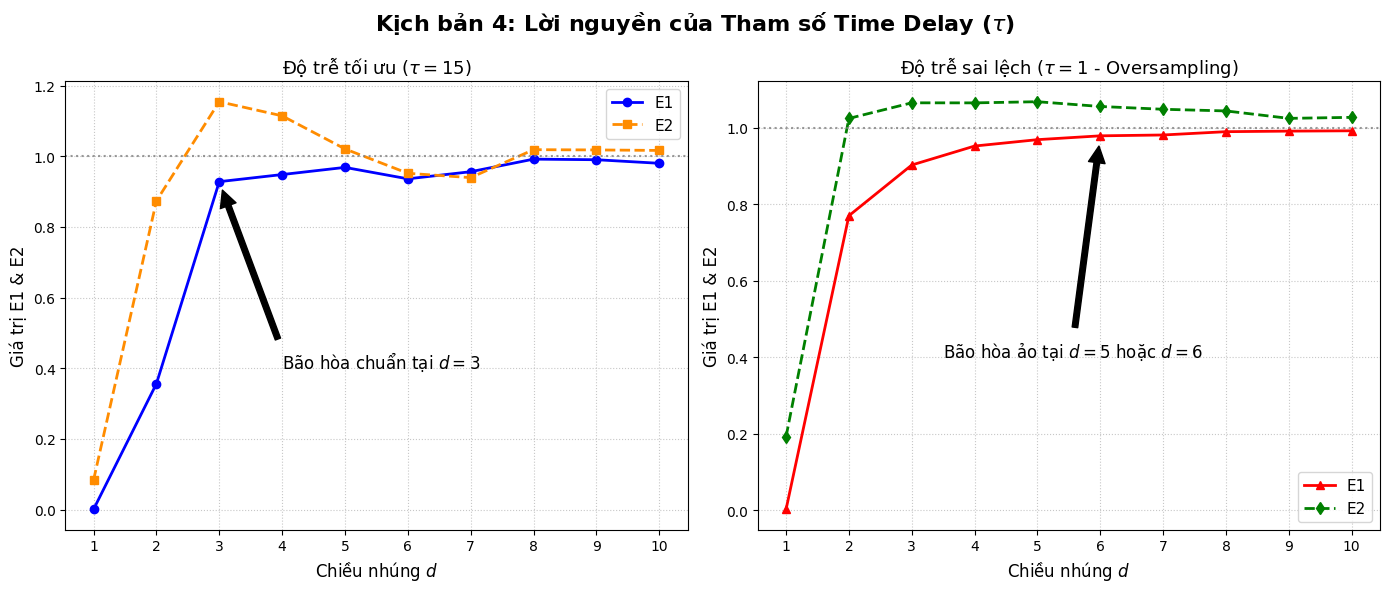

In [9]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Khai báo đường dẫn module gốc
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.phase_space_reconstruction import cao_method

# =====================================================================
# 1. ĐẦU VÀO (INPUT)
# =====================================================================
print("1. Đang khởi tạo dữ liệu Lorenz (N=3000)...")
lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0][:3000]

# =====================================================================
# 2. CHẠY PHƯƠNG PHÁP CAO VỚI HAI ĐỘ TRỄ KHÁC NHAU
# =====================================================================
print("2. Đang tính toán E1 và E2 với tau=15 và tau=1...")
max_dim = 10

# Chạy thuật toán với tau = 15 (Chuẩn KSG / Mutual Information)
dims, E1_opt, E2_opt = cao_method(clean_x, tau=15, max_m=max_dim)

# Chạy thuật toán với tau = 1 (Lấy mẫu quá dày - Oversampling)
dims, E1_bad, E2_bad = cao_method(clean_x, tau=1, max_m=max_dim)

# =====================================================================
# 3. TRỰC QUAN HÓA KẾT QUẢ SO SÁNH
# =====================================================================
print("3. Đang vẽ đồ thị đối chứng...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Kịch bản 4: Lời nguyền của Tham số Time Delay ($\\tau$)", fontsize=16, fontweight='bold')

# Đồ thị 1: Độ trễ tối ưu (tau = 15)
axes[0].plot(dims, E1_opt, marker='o', markersize=6, linewidth=2, color='blue', label='E1')
axes[0].plot(dims, E2_opt, marker='s', markersize=6, linewidth=2, linestyle='--', color='darkorange', label='E2')
axes[0].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8)
axes[0].set_title("Độ trễ tối ưu ($\\tau = 15$)", fontsize=13)
axes[0].set_xlabel("Chiều nhúng $d$", fontsize=12)
axes[0].set_ylabel("Giá trị E1 & E2", fontsize=12)
axes[0].set_xticks(dims)
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(fontsize=11)
axes[0].annotate('Bão hòa chuẩn tại $d=3$', xy=(3, E1_opt[2]), xytext=(4, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

# Đồ thị 2: Độ trễ sai lệch (tau = 1)
axes[1].plot(dims, E1_bad, marker='^', markersize=6, linewidth=2, color='red', label='E1')
axes[1].plot(dims, E2_bad, marker='d', markersize=6, linewidth=2, linestyle='--', color='green', label='E2')
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8)
axes[1].set_title("Độ trễ sai lệch ($\\tau = 1$ - Oversampling)", fontsize=13)
axes[1].set_xlabel("Chiều nhúng $d$", fontsize=12)
axes[1].set_ylabel("Giá trị E1 & E2", fontsize=12)
axes[1].set_xticks(dims)
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(fontsize=11)
axes[1].annotate('Bão hòa ảo tại $d=5$ hoặc $d=6$', xy=(6, E1_bad[5]), xytext=(3.5, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)

plt.tight_layout()
plt.show()